# ENGR 010 — IE Manufacturing Process Analytics Project

**Team:** Vanessa Hui (alongside team members Maia DeLuca, Cameron Guest, and Dylan Gross)  
**Date:** April 2026  

## Project Goal
Build a Python analytics tool that imports manufacturing CSV data, performs quality + process optimization analysis (SPC, capability, bottlenecks), and presents results in a dashboard-style workflow with clear visualizations and interpretations.

# 1. Setup and Data Import

## What we are doing
1. Load the manufacturing dataset from CSV.
2. Validate required columns and clean data types.
3. Automatically detect groups of columns (defects, downtime, quality, time-motion).

## Why this matters
If the dataset is inconsistent (missing columns, wrong types), the analysis and charts can be incorrect or fail.

Detected column groups:
ColumnGroups(defect_cols=['Defects_Dimensional', 'Defects_Surface', 'Defects_Assembly', 'Defects_Material', 'Defects_Other'], downtime_cols=['Downtime_Maintenance', 'Downtime_Setup/Changeover', 'Downtime_Breakdown', 'Downtime_Material Shortage', 'Downtime_Operator Absence'], quality_cols=['Quality_FPY', 'Quality_DPMO', 'Quality_RTY', 'Quality_Sigma_Level', 'Quality_Factor'], timemotion_cols=['TimeMotion_Setup_Time_Minutes', 'TimeMotion_Movement_Time_Seconds', 'TimeMotion_Machine_Time_Seconds', 'TimeMotion_Operator_Utilization', 'TimeMotion_WIP_Average'])

Cycle Time Stats by Line:


,Line,count,mean,median,std,min,max
0,Line A,390,57.806179,57.660,4.473208,48.37,69.17
1,Line B,390,70.307333,70.210,3.237549,61.64,78.54
2,Line C,390,42.162282,41.255,4.423059,32.55,52.92



Defect Rate Stats by Shift:


,Shift,count,mean,median,std,min,max
0,Afternoon,390,0.003782,0.0027,0.003970,0.0,0.0253
1,Morning,390,0.003959,0.0027,0.004185,0.0,0.0221
2,Night,390,0.003615,0.0027,0.003763,0.0,0.0207



Example rows flagged as potential bottlenecks:


,Record_ID,Date,Shift,Line,Production_Volume,Average_Cycle_Time,Defects_Total,Defect_Rate,Downtime_Total,Defects_Dimensional,...,TimeMotion_Movement_Time_Seconds,TimeMotion_Machine_Time_Seconds,TimeMotion_Operator_Utilization,TimeMotion_WIP_Average,Efficiency_Factor,Quality_Factor,Reliability_Factor,Flag_High_CycleTime,Flag_High_Downtime,Flag_High_DefectRate
0,1,2023-01-02,Morning,Line A,361,56.64,4,0.0111,4.394073,1,...,16.1,40.5,0.56,22.4,0.782,0.822,0.796,False,False,True
11,12,2023-01-05,Night,Line A,379,62.73,4,0.0106,0.616816,2,...,15.2,47.5,0.59,8.1,0.751,0.794,0.801,False,False,True
21,22,2023-01-11,Morning,Line A,387,63.88,4,0.0103,6.527613,1,...,14.2,49.7,0.46,15.0,0.738,0.804,0.783,False,False,True
23,24,2023-01-11,Night,Line A,343,64.43,1,0.0029,8.826098,0,...,7.9,56.5,0.55,14.3,0.741,0.820,0.835,False,True,False
27,28,2023-01-13,Morning,Line A,402,62.67,4,0.0100,0.000000,2,...,17.7,44.9,0.58,17.8,0.774,0.782,0.849,False,False,True
33,34,2023-01-17,Morning,Line A,370,63.59,1,0.0027,9.590671,1,...,13.3,50.3,0.58,24.7,0.783,0.839,0.839,False,True,False
43,44,2023-01-20,Afternoon,Line A,382,59.61,5,0.0131,0.000000,1,...,9.1,50.5,0.48,15.4,0.778,0.794,0.821,False,False,True
45,46,2023-01-23,Morning,Line A,405,62.61,4,0.0099,3.811048,1,...,13.1,49.5,0.56,18.4,0.771,0.805,0.819,False,False,True
48,49,2023-01-24,Morning,Line A,401,63.07,4,0.0100,0.000000,1,...,9.4,53.6,0.62,18.3,0.744,0.832,0.852,False,False,True
50,51,2023-01-24,Night,Line A,366,65.19,1,0.0027,8.715000,0,...,11.2,54.0,0.69,10.1,0.755,0.833,0.808,False,True,False


,defect_type,count,percent,cumulative_percent
0,Dimensional,658,33.588566,33.588566
1,Surface,512,26.135784,59.724349
2,Assembly,373,19.040327,78.764676
3,Material,311,15.875447,94.640123
4,Other,105,5.359877,100.000000


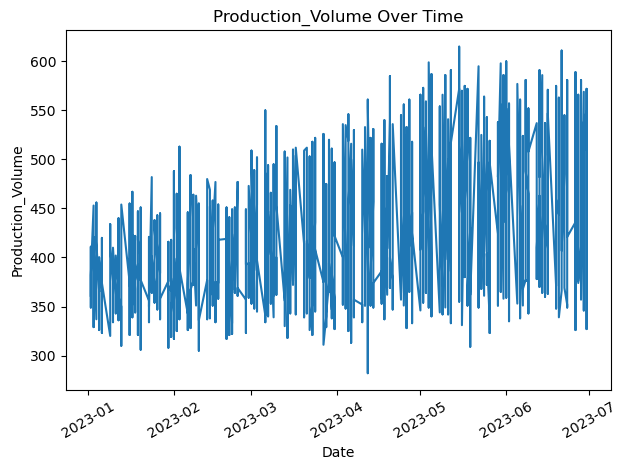

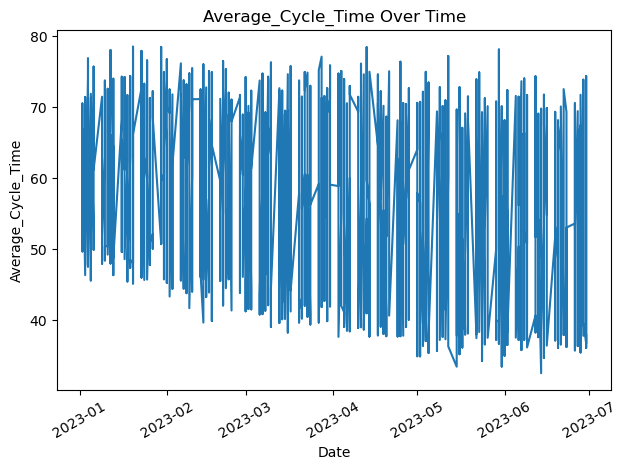

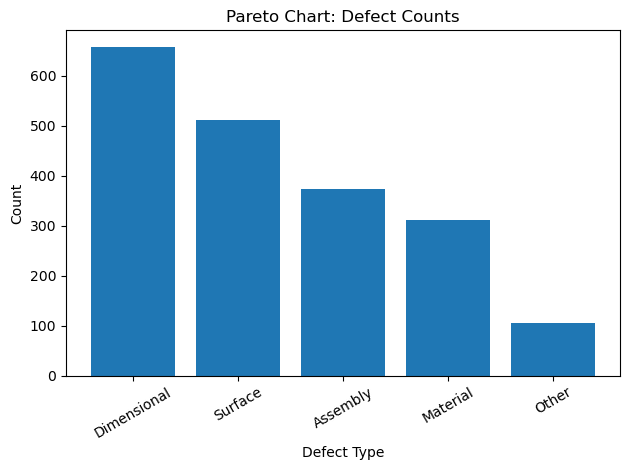

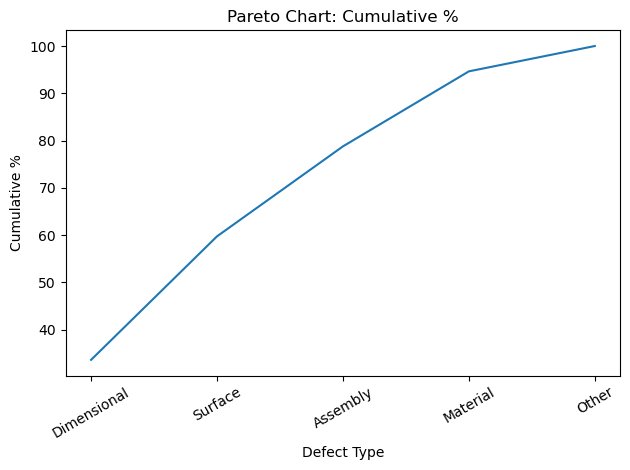

In [12]:
"""
ENGR 010 IE Manufacturing Process Analytics - Starter Code
- Loads manufacturing_process_data.csv
- Cleans + validates columns
- Basic stats + bottleneck flags
- Pareto defects + time series plots
You can expand this into control charts (X-bar/R), capability (Cp/Cpk), and a dashboard.
"""

from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 0) Config / Constants
# -----------------------------
REQUIRED_BASE_COLS = [
    "Date", "Shift", "Line",
    "Production_Volume", "Average_Cycle_Time",
    "Defects_Total", "Defect_Rate", "Downtime_Total"
]

PREFIX_DEFECT = "Defects_"
PREFIX_DOWNTIME = "Downtime_"
PREFIX_QUALITY = "Quality_"
PREFIX_TIMEMOTION = "TimeMotion_"


@dataclass
class ColumnGroups:
    defect_cols: List[str]
    downtime_cols: List[str]
    quality_cols: List[str]
    timemotion_cols: List[str]


# -----------------------------
# 1) Data Loading + Validation
# -----------------------------
def load_data(csv_path: str) -> pd.DataFrame:
    """
    Load manufacturing CSV into a DataFrame with basic error handling.
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Couldn't find '{csv_path}'. Put it in the same folder as this notebook "
            "or pass the correct path."
        )
    except Exception as e:
        raise RuntimeError(f"Failed to read CSV: {e}")

    return df


def validate_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure required columns exist, convert types, and create convenient datetime column.
    """
    missing = [c for c in REQUIRED_BASE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Convert Date to datetime
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    if df["Date"].isna().any():
        bad_rows = df[df["Date"].isna()].index.tolist()[:10]
        raise ValueError(f"Some Date values couldn't be parsed. Example bad row indices: {bad_rows}")

    # Make sure numeric columns are numeric
    numeric_cols = ["Production_Volume", "Average_Cycle_Time", "Defects_Total", "Defect_Rate", "Downtime_Total"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop rows with critical NaNs (or you can fill them later)
    df = df.dropna(subset=numeric_cols)

    return df


def detect_metric_columns(df: pd.DataFrame) -> ColumnGroups:
    """
    Auto-detect metric columns created by the generator:
    Defects_*, Downtime_*, Quality_*, TimeMotion_*
    """
    defect_cols = [c for c in df.columns if c.startswith(PREFIX_DEFECT) and c != "Defects_Total"]
    downtime_cols = [c for c in df.columns if c.startswith(PREFIX_DOWNTIME) and c != "Downtime_Total"]
    quality_cols = [c for c in df.columns if c.startswith(PREFIX_QUALITY)]
    timemotion_cols = [c for c in df.columns if c.startswith(PREFIX_TIMEMOTION)]
    return ColumnGroups(defect_cols, downtime_cols, quality_cols, timemotion_cols)


# -----------------------------
# 2) Core Analytics Functions
# -----------------------------
def basic_stats(df: pd.DataFrame, group_by: List[str], metric: str) -> pd.DataFrame:
    """
    Compute mean/median/std for a metric grouped by group_by columns.
    """
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not in dataframe columns.")

    summary = (
        df.groupby(group_by)[metric]
          .agg(["count", "mean", "median", "std", "min", "max"])
          .reset_index()
    )
    return summary


def find_bottlenecks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Simple bottleneck finder: flags the worst rows by cycle time, downtime, and defect rate.
    (You’ll likely refine this later.)
    """
    df2 = df.copy()

    # Example thresholds using percentiles
    ct_thresh = df2["Average_Cycle_Time"].quantile(0.90)
    dt_thresh = df2["Downtime_Total"].quantile(0.90)
    dr_thresh = df2["Defect_Rate"].quantile(0.90)

    df2["Flag_High_CycleTime"] = df2["Average_Cycle_Time"] >= ct_thresh
    df2["Flag_High_Downtime"] = df2["Downtime_Total"] >= dt_thresh
    df2["Flag_High_DefectRate"] = df2["Defect_Rate"] >= dr_thresh

    return df2


def pareto_defects(df: pd.DataFrame, defect_cols: List[str]) -> pd.DataFrame:
    """
    Build a Pareto table from Defects_* columns.
    Returns: defect_type, count, percent, cumulative_percent
    """
    if not defect_cols:
        return pd.DataFrame(columns=["defect_type", "count", "percent", "cumulative_percent"])

    totals = df[defect_cols].sum(axis=0).sort_values(ascending=False)
    pareto = totals.reset_index()
    pareto.columns = ["defect_type", "count"]

    total_count = pareto["count"].sum()
    pareto["percent"] = (pareto["count"] / total_count * 100) if total_count > 0 else 0
    pareto["cumulative_percent"] = pareto["percent"].cumsum()

    # Clean up names: Defects_Scratch -> Scratch
    pareto["defect_type"] = pareto["defect_type"].str.replace(PREFIX_DEFECT, "", regex=False)
    return pareto


# -----------------------------
# 3) Plotting Helpers (Matplotlib)
# -----------------------------
def plot_time_series(df: pd.DataFrame, metric: str, line: Optional[str] = None) -> None:
    """
    Time-series plot for a metric; optionally filter to a specific line.
    """
    d = df.copy()
    if line is not None:
        d = d[d["Line"] == line]

    d = d.sort_values("Date")
    plt.figure()
    plt.plot(d["Date"], d[metric])
    plt.title(f"{metric} Over Time" + (f" - {line}" if line else ""))
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


def plot_pareto(pareto_df: pd.DataFrame) -> None:
    """
    Pareto bar chart + cumulative percentage line (2 plot types in one figure).
    """
    if pareto_df.empty:
        print("No defect columns found to make a Pareto chart.")
        return

    plt.figure()
    plt.bar(pareto_df["defect_type"], pareto_df["count"])
    plt.title("Pareto Chart: Defect Counts")
    plt.xlabel("Defect Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(pareto_df["defect_type"], pareto_df["cumulative_percent"])
    plt.title("Pareto Chart: Cumulative %")
    plt.xlabel("Defect Type")
    plt.ylabel("Cumulative %")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) Run Section (Notebook friendly)
# -----------------------------
CSV_PATH = "manufacturing_process_data.csv"  # change if yours is elsewhere

df_raw = load_data(CSV_PATH)
df = validate_and_clean(df_raw)

groups = detect_metric_columns(df)
print("Detected column groups:")
print(groups)

# Quick summaries (these are good “report” outputs)
summary_line = basic_stats(df, ["Line"], "Average_Cycle_Time")
summary_shift = basic_stats(df, ["Shift"], "Defect_Rate")
print("\nCycle Time Stats by Line:")
display(summary_line)
print("\nDefect Rate Stats by Shift:")
display(summary_shift)

# Bottleneck flags
df_flagged = find_bottlenecks(df)
print("\nExample rows flagged as potential bottlenecks:")
display(df_flagged[df_flagged[["Flag_High_CycleTime","Flag_High_Downtime","Flag_High_DefectRate"]].any(axis=1)].head(10))

# Pareto + plots
pareto = pareto_defects(df, groups.defect_cols)
display(pareto.head(10))

plot_time_series(df, "Production_Volume")
plot_time_series(df, "Average_Cycle_Time")
plot_pareto(pareto)

# 2. Methods: SPC (X̄ & R Charts), Process Capability, and Bottleneck Detection

## SPC (Statistical Process Control)
We use X̄ and R charts to monitor whether the process is stable over time:
- **X̄ chart** tracks subgroup means (center and drift)
- **R chart** tracks subgroup ranges (variation)

## Capability (Cp and Cpk)
Capability compares the process spread/center to specification limits:
- **Cp**: potential capability (spread vs spec width)
- **Cpk**: actual capability (accounts for process center shift)

## Bottlenecks
We flag worst-performing observations to guide improvement:
- high cycle time
- high downtime
- high defect rate

In [13]:
import math
from typing import Optional

# -----------------------------
# 5) SPC (X-bar and R Charts)
# -----------------------------
def add_subgroup_id(df: pd.DataFrame, subgroup_cols: list[str]) -> pd.DataFrame:
    """
    Create a SubgroupID column for SPC subgrouping, e.g. ["Date","Shift","Line"].
    """
    d = df.copy()
    for c in subgroup_cols:
        if c not in d.columns:
            raise ValueError(f"Subgroup column '{c}' not found.")
    d["SubgroupID"] = d[subgroup_cols].astype(str).agg("|".join, axis=1)
    return d


def xbar_r_table(df: pd.DataFrame, value_col: str, subgroup_col: str = "SubgroupID") -> pd.DataFrame:
    """
    Build subgroup summary containing Xbar, R, n for each subgroup.
    """
    if value_col not in df.columns:
        raise ValueError(f"Value column '{value_col}' not found.")
    if subgroup_col not in df.columns:
        raise ValueError(f"Subgroup column '{subgroup_col}' not found.")

    g = df.groupby(subgroup_col)[value_col]
    out = pd.DataFrame({
        "Xbar": g.mean(),
        "R": g.max() - g.min(),
        "n": g.count()
    }).reset_index()

    return out


def spc_constants(n: int) -> dict[str, float]:
    """
    SPC constants for X-bar/R charts for subgroup size n (2..10).
    Returns A2, D3, D4.
    """
    table = {
        2:  {"A2": 1.880, "D3": 0.000, "D4": 3.267},
        3:  {"A2": 1.023, "D3": 0.000, "D4": 2.574},
        4:  {"A2": 0.729, "D3": 0.000, "D4": 2.282},
        5:  {"A2": 0.577, "D3": 0.000, "D4": 2.114},
        6:  {"A2": 0.483, "D3": 0.000, "D4": 2.004},
        7:  {"A2": 0.419, "D3": 0.076, "D4": 1.924},
        8:  {"A2": 0.373, "D3": 0.136, "D4": 1.864},
        9:  {"A2": 0.337, "D3": 0.184, "D4": 1.816},
        10: {"A2": 0.308, "D3": 0.223, "D4": 1.777},
    }
    if n not in table:
        raise ValueError(f"Subgroup size n={n} not supported for constants (use 2..10).")
    return table[n]


def spc_limits_xbar_r(xbar_r_df: pd.DataFrame) -> dict[str, float]:
    """
    Compute control limits for X-bar and R charts based on average subgroup size.
    If subgroup sizes vary, we use rounded average n (common class approach).
    """
    if xbar_r_df.empty:
        raise ValueError("xbar_r_df is empty.")

    n_avg = int(round(xbar_r_df["n"].mean()))
    n_avg = max(2, min(10, n_avg))  # clamp to 2..10 for constants
    const = spc_constants(n_avg)

    xbarbar = xbar_r_df["Xbar"].mean()
    rbar = xbar_r_df["R"].mean()

    ucl_x = xbarbar + const["A2"] * rbar
    lcl_x = xbarbar - const["A2"] * rbar

    ucl_r = const["D4"] * rbar
    lcl_r = const["D3"] * rbar

    return {
        "n_used": n_avg,
        "Xbarbar": xbarbar,
        "Rbar": rbar,
        "UCL_X": ucl_x,
        "CL_X": xbarbar,
        "LCL_X": lcl_x,
        "UCL_R": ucl_r,
        "CL_R": rbar,
        "LCL_R": lcl_r
    }


def plot_xbar_r(xbar_r_df: pd.DataFrame, limits: dict[str, float], title_prefix: str = "") -> None:
    """
    Plot X-bar chart and R chart.
    """
    # X-bar chart
    plt.figure()
    plt.plot(xbar_r_df["Xbar"].values)
    plt.axhline(limits["CL_X"])
    plt.axhline(limits["UCL_X"])
    plt.axhline(limits["LCL_X"])
    plt.title(f"{title_prefix} X̄ Chart (n≈{limits['n_used']})")
    plt.xlabel("Subgroup Index")
    plt.ylabel("X̄")
    plt.tight_layout()
    plt.show()

    # R chart
    plt.figure()
    plt.plot(xbar_r_df["R"].values)
    plt.axhline(limits["CL_R"])
    plt.axhline(limits["UCL_R"])
    plt.axhline(limits["LCL_R"])
    plt.title(f"{title_prefix} R Chart (n≈{limits['n_used']})")
    plt.xlabel("Subgroup Index")
    plt.ylabel("R")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 6) Process Capability (Cp, Cpk)
# -----------------------------
def process_capability(series: pd.Series, lsl: float, usl: float) -> dict[str, float]:
    """
    Compute Cp and Cpk using sample std dev.
    Assumes normally distributed process data (class-level approach).
    """
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        raise ValueError("No valid numeric data for capability.")

    mu = x.mean()
    sigma = x.std(ddof=1)

    if sigma <= 0:
        raise ValueError("Sigma is zero/invalid; capability cannot be computed.")

    cp = (usl - lsl) / (6 * sigma)
    cpk = min((usl - mu) / (3 * sigma), (mu - lsl) / (3 * sigma))

    return {"mean": mu, "std": sigma, "Cp": cp, "Cpk": cpk, "LSL": lsl, "USL": usl}



# -----------------------------
# 7) Bottleneck Report (more “engineering” style)
# -----------------------------
def bottleneck_report(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Produce a ranked report using normalized metrics:
    - high cycle time (bad)
    - high downtime (bad)
    - high defect rate (bad)
    """
    d = df.copy()

    # Normalize (0..1) using min-max so we can combine into a simple score
    def minmax(s: pd.Series) -> pd.Series:
        s = pd.to_numeric(s, errors="coerce")
        mn, mx = s.min(), s.max()
        if mx == mn:
            return pd.Series([0]*len(s), index=s.index)
        return (s - mn) / (mx - mn)

    d["CycleTime_norm"] = minmax(d["Average_Cycle_Time"])
    d["Downtime_norm"] = minmax(d["Downtime_Total"])
    d["DefectRate_norm"] = minmax(d["Defect_Rate"])

    # Weighted score (edit weights if you want)
    d["BottleneckScore"] = (
        0.45 * d["CycleTime_norm"] +
        0.35 * d["Downtime_norm"] +
        0.20 * d["DefectRate_norm"]
    )

    cols = ["Date", "Shift", "Line", "Production_Volume", "Average_Cycle_Time", "Downtime_Total", "Defect_Rate", "BottleneckScore"]
    return d.sort_values("BottleneckScore", ascending=False)[cols].head(top_n)

# 3. Results: SPC (X̄ and R Charts)

## What we are doing
1. Create subgroups (Date + Shift + Line).
2. Build an X̄/R table for a selected metric.
3. Compute control limits and plot X̄ and R charts.

## Interpretation (what to look for)
- Points outside UCL/LCL indicate potential special-cause variation.
- Patterns/trends may indicate drift even if within limits.

SPC limits used: {'n_used': 2, 'Xbarbar': np.float64(56.758598290598286), 'Rbar': np.float64(0.0), 'UCL_X': np.float64(56.758598290598286), 'CL_X': np.float64(56.758598290598286), 'LCL_X': np.float64(56.758598290598286), 'UCL_R': np.float64(0.0), 'CL_R': np.float64(0.0), 'LCL_R': np.float64(0.0)}


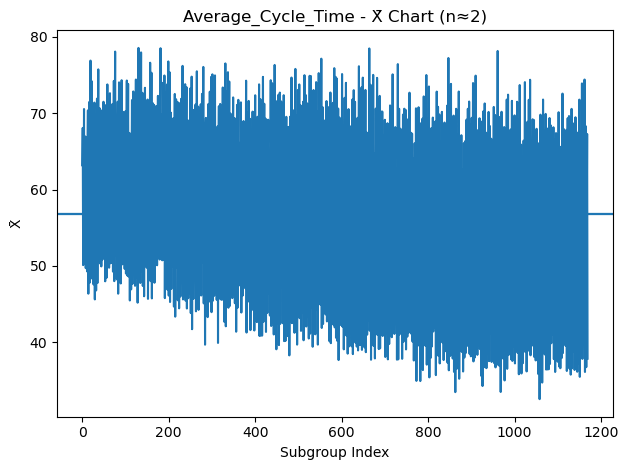

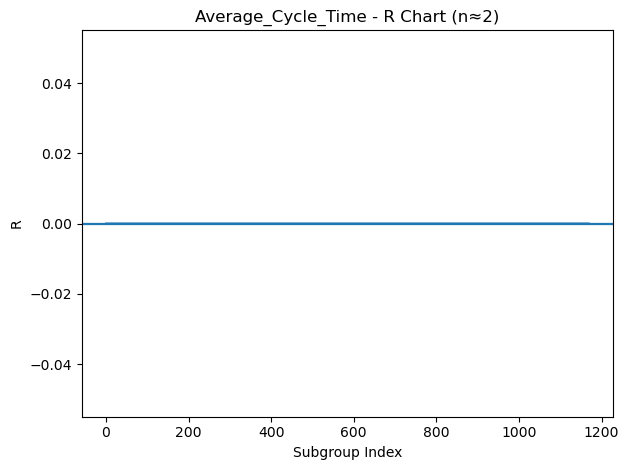

In [14]:
# --- Choose what metric you want to control chart ---
SPC_VALUE_COL = "Average_Cycle_Time"  # common choice

# --- Build subgrouped dataset ---
df_spc = add_subgroup_id(df, ["Date", "Shift", "Line"])

# --- Create subgroup table ---
xbr = xbar_r_table(df_spc, value_col=SPC_VALUE_COL, subgroup_col="SubgroupID")

# --- Limits + plots ---
limits = spc_limits_xbar_r(xbr)
print("SPC limits used:", limits)

plot_xbar_r(xbr, limits, title_prefix=f"{SPC_VALUE_COL} -")

# 4. Results: Process Capability (Cp and Cpk)

## What we are doing
Compute Cp/Cpk for a chosen metric using specification limits (LSL, USL).

## Requirement note
You must define reasonable LSL/USL values. In a real plant these come from engineering specs. Here, we choose a justifiable example and state it clearly.

In [15]:
# Example spec limits (YOU MUST CHOOSE + EXPLAIN THESE IN YOUR REPORT)
# For example, suppose acceptable cycle time is between 45 and 75 seconds.
LSL = 45
USL = 75

cap = process_capability(df["Average_Cycle_Time"], lsl=LSL, usl=USL)
cap

{'mean': np.float64(56.758598290598286),
 'std': 12.22057611850851,
 'Cp': 0.40914601337225964,
 'Cpk': np.float64(0.32073224089627705),
 'LSL': 45,
 'USL': 75}

# 5. Results: Bottleneck Report

## What we are doing
Create a ranked list of worst-performing observations using a combined bottleneck score
(high cycle time, high downtime, high defect rate).

## Why this matters
This helps decide where to focus improvement efforts first.

In [16]:
report = bottleneck_report(df, top_n=10)
report

,Date,Shift,Line,Production_Volume,Average_Cycle_Time,Downtime_Total,Defect_Rate,BottleneckScore
812,2023-01-16,Night,Line C,432,49.62,34.165749,0.0116,0.608725
500,2023-02-21,Night,Line B,346,76.51,10.571226,0.0000,0.538431
451,2023-01-30,Afternoon,Line B,308,78.50,2.479185,0.0065,0.526389
171,2023-03-22,Morning,Line A,379,60.55,21.893192,0.0026,0.518804
585,2023-04-03,Morning,Line B,352,74.53,7.889428,0.0028,0.513718
604,2023-04-11,Afternoon,Line B,352,76.14,6.001671,0.0028,0.510133
120,2023-02-27,Morning,Line A,404,60.19,17.675758,0.0074,0.510022
829,2023-01-24,Afternoon,Line C,435,51.47,12.095657,0.0253,0.509037
470,2023-02-07,Night,Line B,328,73.41,7.873048,0.0030,0.504173
431,2023-01-19,Night,Line B,337,74.40,1.619971,0.0089,0.496442


# 6. Simple Dashboard (Interactive Filters)

## What we are doing
Create a basic interactive dashboard using dropdown filters:
- Line
- Shift
- Metric

The plots update based on the selections.

In [17]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception as e:
    print("ipywidgets not available. If needed, install with: pip install ipywidgets")
    raise

lines = sorted(df["Line"].unique().tolist())
shifts = sorted(df["Shift"].unique().tolist())

metric_options = [
    "Production_Volume",
    "Average_Cycle_Time",
    "Defect_Rate",
    "Downtime_Total"
]

line_dd = widgets.Dropdown(options=["ALL"] + lines, value="ALL", description="Line:")
shift_dd = widgets.Dropdown(options=["ALL"] + shifts, value="ALL", description="Shift:")
metric_dd = widgets.Dropdown(options=metric_options, value="Average_Cycle_Time", description="Metric:")

out = widgets.Output()

def filtered_df() -> pd.DataFrame:
    d = df.copy()
    if line_dd.value != "ALL":
        d = d[d["Line"] == line_dd.value]
    if shift_dd.value != "ALL":
        d = d[d["Shift"] == shift_dd.value]
    return d.sort_values("Date")

def update_dashboard(*args):
    with out:
        clear_output(wait=True)
        d = filtered_df()
        print(f"Rows: {len(d)} | Line: {line_dd.value} | Shift: {shift_dd.value} | Metric: {metric_dd.value}")
        display(basic_stats(d, ["Line"], metric_dd.value))
        plot_time_series(d, metric_dd.value)

for w in [line_dd, shift_dd, metric_dd]:
    w.observe(update_dashboard, names="value")

display(widgets.VBox([line_dd, shift_dd, metric_dd, out]))
update_dashboard()

## Creative Feature: Best vs Worst Production Line

To enhance the analysis, a simple comparison was added to identify the best and worst performing production lines based on defect rate. This helps quickly highlight which line is most efficient and which may need improvement.

In [20]:
# Find best and worst production lines based on defect rate
best_line = df.groupby("Line")["Defect_Rate"].mean().idxmin()
worst_line = df.groupby("Line")["Defect_Rate"].mean().idxmax()

print("Best Production Line:", best_line)
print("Worst Production Line:", worst_line)

Best Production Line: Line B
Worst Production Line: Line C


## Conclusion

This project developed a comprehensive manufacturing process analysis and quality control tool using Python. By integrating data management, statistical analysis, and visualization techniques, the application effectively monitors production performance across multiple lines and identifies key areas for improvement.

The analysis revealed variability in cycle times, defect rates, and machine performance, indicating opportunities to improve consistency and efficiency. Control charts helped assess process stability, while Pareto analysis highlighted the most significant contributors to defects. Additionally, process capability metrics (Cp and Cpk) provided insight into how well the process meets specification limits.

Based on these findings, several recommendations can be made: standardizing processes across production lines to reduce variability, implementing targeted maintenance for underperforming machines, and focusing defect reduction efforts on the most frequent issues identified. Overall, this tool demonstrates how data-driven decision-making can enhance production quality and operational efficiency in a manufacturing environment.
